![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [111]:
import warnings
warnings.filterwarnings('ignore')

In [112]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
#Se crean columnas dummies que sean de tipo entero
data = data.join(pd.get_dummies(data['Model'], prefix='M', dtype=int))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,0,0,0,1,0,0,0
11,13995,2014,39972,0,0,0,0,1,0,0
167,17941,2016,18989,0,0,0,0,0,1,0
225,12493,2014,51330,0,0,0,1,0,0,0
270,7994,2007,116065,0,1,0,0,0,0,0


In [113]:
# Librerias adicionales
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from IPython.display import Markdown, display
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

In [114]:
display(Markdown(f"""### Datos iniciales:
                 \n Los datos cargados originalmente se componen de {data.shape[0]} filas, cada una representa una observación y {data.shape[1]} columnas, cada columna representa una variable."""))

# Análisis Valores Nulos\n
display(Markdown(f""" ### Análisis Valores Nulos:
    \n El dataset resultante tiene {data.isnull().sum().sum()} valores nulos."""))

### Datos iniciales:
                 
 Los datos cargados originalmente se componen de 10495 filas, cada una representa una observación y 10 columnas, cada columna representa una variable.

 ### Análisis Valores Nulos:
    
 El dataset resultante tiene 0 valores nulos.

In [115]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [116]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [117]:
# Celda 1

# Definición de la función que calcula el mse
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        #Se usa la varianza para poder decir que tan parecidos son los números entre sí
        return y.var()
    
# Definición de la función mse para calular la ganancia de una variable predictora j dado el punto de corte k
def mse_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    gain = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return gain

# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        return dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean() 
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree):
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

Para poder hacer un arbol de decisión manual que de el mejor resultado posible, se procede a iterar sobre un rango para cambiar la profundidad máxima.

Adicionalmente, para poder ver le impacto del cambio del profundidad en las métricas de evaluación, se procede a gráficar el resultado obtenido.
                 
 Por otro lado, se gráfica también el precio real vs el precio predicho para las primeras 1000 observaciones de test

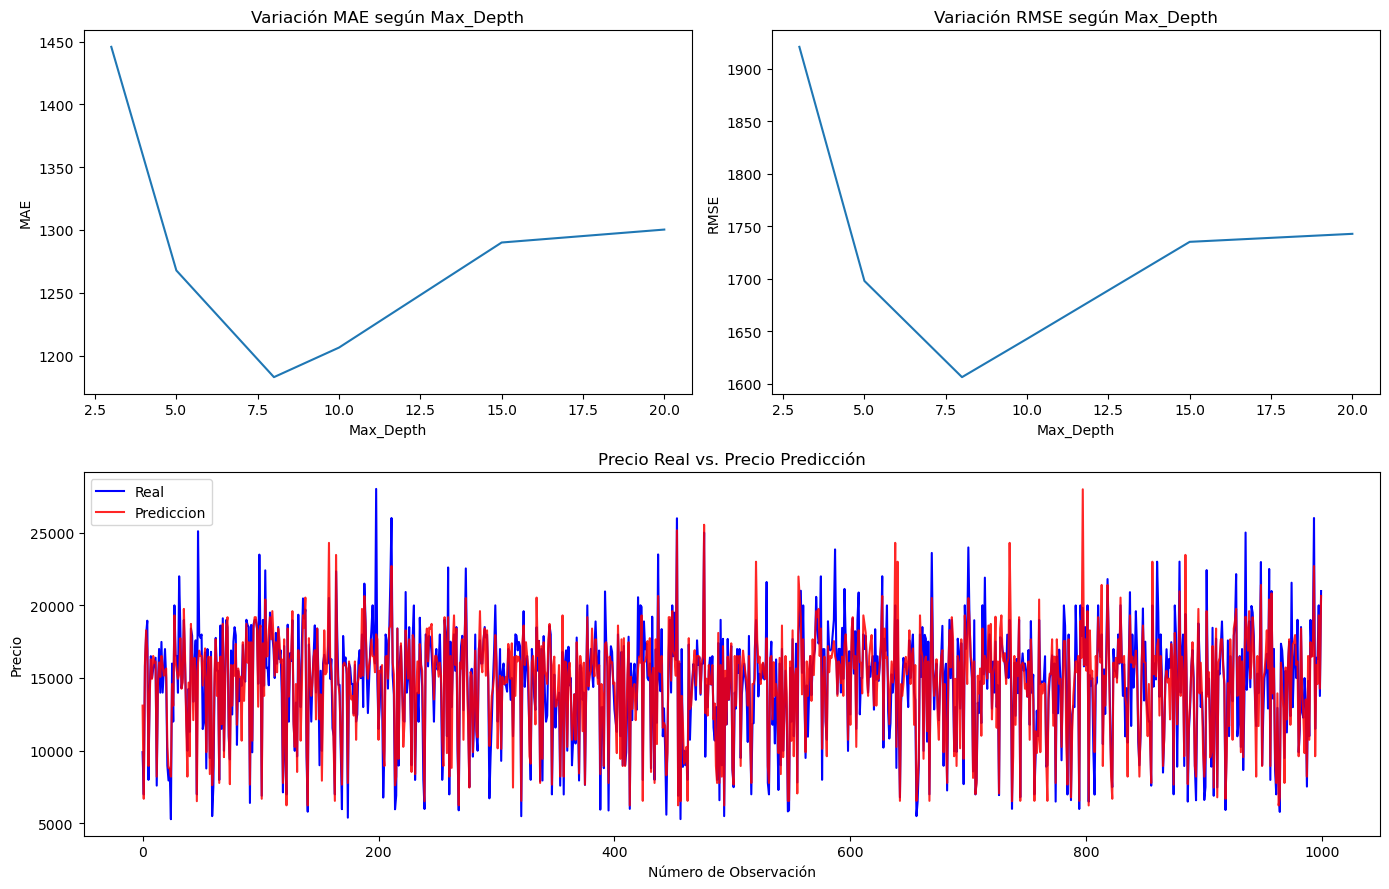

Finalmente, se puede ver que el modelo resultante, usa una ***profundidad de 8*** nodos y cuenta con un ***RMSE de 1606.2958*** y un ***MAE de 
                 1182.8332***, resultado de predecir sobre los datos de test establecidos.

                 
 Se puede decir que el error promedio del modelo al predecir el precio de los carros es de 1.182 USD. Por otro lado, se tiene un error cuadrado tipico de 1.606 USD, por 
                    lo que podemos decir que hay algunas veces en las que el modelo se equivoca mucho más que en otras. Si se quisiera mejorar el poder predictivo del modelo, se podrían
                    agregar algunos predictores adicionales al año y las millas recorridas.

                
 Lo anterior se peude confirmar dado el resulado que se observa en la gráfica, en donde se ve que la predicción no alcanza al valor de ciertos 'picos' y que para otros 
                   casos ocurre lo contrario, en donde el valor predicho es mucho mayor al real. Adicional, este comportamiento se presenta más frecuentemente para precios mayores a 
                   15.000 USD.

In [141]:
display(Markdown(f"""Para poder hacer un arbol de decisión manual que de el mejor resultado posible, se procede a iterar sobre un rango para cambiar la profundidad máxima."""))

# Creación de lista de valores para iterar sobre diferentes valores de max_depth
estimator_range = [3, 5, 8, 10, 15, 20]

# Definición de lista para almacenar las métrcias (MAE y RMSE) para cada valor de max_depth
metrics_mae = []
metrics_rmse = []
trees_list = []
y_pred_list = []

for estimator in estimator_range:
    tree = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=estimator, num_pct=10)
    y_pred = tree_predict(X_test, tree)
    mae_calculated = metrics.mean_absolute_error(y_test, y_pred)
    mse_calculated = metrics.mean_squared_error(y_test, y_pred)
    rmse_calculated = np.sqrt(mse_calculated)
    metrics_rmse.append(rmse_calculated)
    metrics_mae.append(mae_calculated)
    y_pred_list.append(y_pred)
    trees_list.append(tree)

#Se busca la posición del valor mínimo encontrado dada la iteración sobre la profundidad
best_idx = np.argmin(metrics_rmse) 

#e extraen los mejores valores resultantes de la iteración
best_depth = estimator_range[best_idx]
best_rmse = metrics_rmse[best_idx]
best_pred = y_pred_list[best_idx] 
best_mae = metrics_mae[best_idx]
best_tree = trees_list[best_idx] 

display(Markdown(f"""Adicionalmente, para poder ver le impacto del cambio del profundidad en las métricas de evaluación, se procede a gráficar el resultado obtenido.
                 \n Por otro lado, se gráfica también el precio real vs el precio predicho para las primeras 1000 observaciones de test"""))

plt.figure(figsize=(14, 9))
plt.subplot(2, 2, 1)
plt.plot(estimator_range, metrics_mae)
plt.title('Variación MAE según Max_Depth')
plt.xlabel('Max_Depth')
plt.ylabel('MAE')

plt.subplot(2, 2, 2)
plt.plot(estimator_range, metrics_rmse)
plt.title('Variación RMSE según Max_Depth')
plt.xlabel('Max_Depth')
plt.ylabel('RMSE')

plt.subplot(2, 1, 2)
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(best_pred[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()

plt.tight_layout()
plt.show()

display(Markdown(f"""Finalmente, se puede ver que el modelo resultante, usa una ***profundidad de {best_depth}*** nodos y cuenta con un ***RMSE de {best_rmse:.4f}*** y un ***MAE de 
                 {best_mae:.4f}***, resultado de predecir sobre los datos de test establecidos.
                 
                 \n Se puede decir que el error promedio del modelo al predecir el precio de los carros es de 1.182 USD. Por otro lado, se tiene un error cuadrado tipico de 1.606 USD, por 
                    lo que podemos decir que hay algunas veces en las que el modelo se equivoca mucho más que en otras. Si se quisiera mejorar el poder predictivo del modelo, se podrían
                    agregar algunos predictores adicionales al año y las millas recorridas.
                   
                \n Lo anterior se peude confirmar dado el resulado que se observa en la gráfica, en donde se ve que la predicción no alcanza al valor de ciertos 'picos' y que para otros 
                   casos ocurre lo contrario, en donde el valor predicho es mucho mayor al real. Adicional, este comportamiento se presenta más frecuentemente para precios mayores a 
                   15.000 USD."""))


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

Se implementa un modelo de ***Bagging*** manual en donde se entrenan 10 arboles de decisión simples pero cada uno de ellos cuenta con muestras diferentes (incluyendo
                 la posibilidad de que las muestras cuenten con observaciones repetidas) y luego se promedia el resultado de los 10, lo cual genera mayor diversidad, dado que cada árbol
                 se entrena con carros diferentes. 

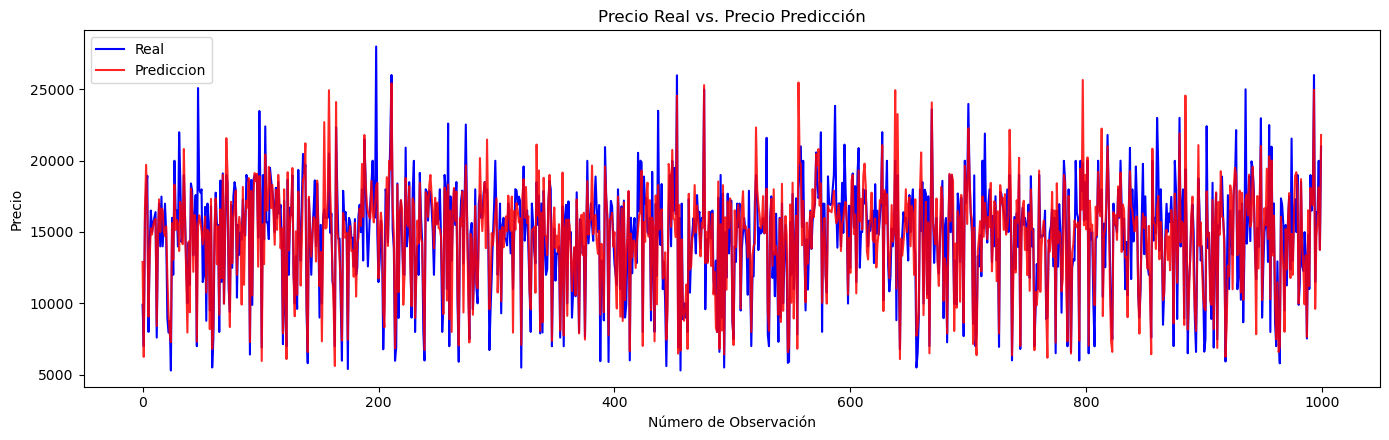

Finalmente, se tiene que el modelo resultante cuenta con un ***RMSE de 1786.4766*** y un ***MAE de 1325.2992***. Los cuales muestran que el modelo tiene 
                 un desempeño inferior al modelo implementado de árbol de decisión manual. Teniendo que el error promedio es de -142.5 USD menos y que el RMSE es de 
                 -180.2 USD menos, lo cual se puede ver representado en la gráfica de los resultados reales vs predichos para las primeras 1000 observaciones, en donde 
                 se ven que el desempeño es similar al anterior pero que para algunos 'picos' el resultado de la predicción es mayor o menor al resultado real, provocando que haya más 
                 diferencia entre los valores y aumenten los valores de las métricas.

In [119]:
# Celda 2

num_arboles = 10
predicciones = np.zeros((X_test.shape[0], num_arboles))

for i in range(num_arboles):
    #Generar indices aleatoios con el mismo número de observaciones
    muestra = np.random.choice(np.arange(X_train.shape[0]), size=X_train.shape[0], replace=True)

    #Se generan X y Y para los indices que se generaron
    X_muestra = X_train.iloc[muestra]
    Y_muestra = y_train.iloc[muestra]

    #Se entrena un arbol de decisión con las muestras
    modelo = DecisionTreeRegressor(random_state=i)
    modelo.fit(X_muestra, Y_muestra)
    predicciones[:,i] = modelo.predict(X_test)

y_pred_final_bagg_m = predicciones.mean(axis=1)
mae_bagg_m = metrics.mean_absolute_error(y_test, y_pred_final_bagg_m)
mse_bagg_m = metrics.mean_squared_error(y_test, y_pred_final_bagg_m)
rmse_bagg_m = np.sqrt(mse_bagg_m)

display(Markdown(f"""Se implementa un modelo de ***Bagging*** manual en donde se entrenan 10 arboles de decisión simples pero cada uno de ellos cuenta con muestras diferentes (incluyendo
                 la posibilidad de que las muestras cuenten con observaciones repetidas) y luego se promedia el resultado de los 10, lo cual genera mayor diversidad, dado que cada árbol
                 se entrena con carros diferentes. """))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_final_bagg_m[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

diff_mae_tree_vs_baggm = best_mae - mae_bagg_m
diff_rmse_tree_vs_baggm = best_rmse - rmse_bagg_m

display(Markdown(f"""Finalmente, se tiene que el modelo resultante cuenta con un ***RMSE de {rmse_bagg_m:.4f}*** y un ***MAE de {mae_bagg_m:.4f}***. Los cuales muestran que el modelo tiene 
                 un desempeño inferior al modelo implementado de árbol de decisión manual. Teniendo que el error promedio es de {diff_mae_tree_vs_baggm:.1f} USD menos y que el RMSE es de 
                 {diff_rmse_tree_vs_baggm:.1f} USD menos, lo cual se puede ver representado en la gráfica de los resultados reales vs predichos para las primeras 1000 observaciones, en donde 
                 se ven que el desempeño es similar al anterior pero que para algunos 'picos' el resultado de la predicción es mayor o menor al resultado real, provocando que haya más 
                 diferencia entre los valores y aumenten los valores de las métricas."""))

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` del árbol de decisión igual a `log(n_features)` y comenten sobre el desempeño del modelo.

Se implementa un modelo de Bagging haciendo uso de la librería sklearn y estableciendo los valores de algunos parámetros como; profundidad máxima de 10 y ***max_features***
                 igual al $log2$ de la cantidad total de variables, limitando así la cantidad de información que cada árbol usar para poder predecir.

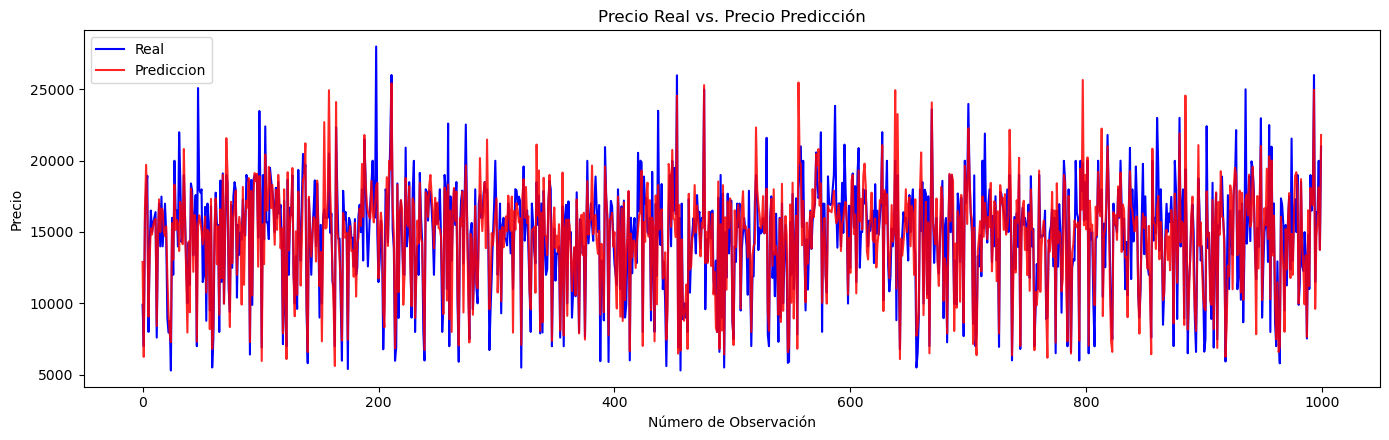

Después de hacer la implementación de un modelo bagging usando parametros específicos, se obtiene que el modelo resultante cuenta con un ***RMSE de 1786.4766*** 
                 y un ***MAE de 1325.2992***. Los cuales muestran que el modelo tiene un desempeño inferior a ambos modelos implementados anteriormente. Teniendo que el error promedio 
                 es de -142.5 USD menos y que el RMSE es de -180.2 USD menos, lo cual se puede ver representado en la gráfica de los resultados 
                 reales vs predichos para las primeras 1000 observaciones.

                 
 Adicionalmente, podemos decir que dados los datos disponibles, las estrategias de generar diversidad modificando las obrevaciones y columnas que cada arbol recibe, no
                 están generando una mejora en el poder predictivo, sino que por el contrario, están provocando que el modelo final se equivoque más cuando predice sobre observaciones 
                 nuevas.

In [120]:
# Celda 3
num_arboles = 10
max_features = int(np.log2(X_train.shape[1]))

bagging_model = BaggingRegressor(max_features=max_features, n_estimators=num_arboles, bootstrap=True, random_state=20)
bagging_model.fit(X_train,y_train)

y_pred_final_bagg = predicciones.mean(axis=1)
mae_bagg = metrics.mean_absolute_error(y_test, y_pred_final_bagg)
mse_bagg = metrics.mean_squared_error(y_test, y_pred_final_bagg)
rmse_bagg = np.sqrt(mse_bagg)

display(Markdown(f"""Se implementa un modelo de Bagging haciendo uso de la librería sklearn y estableciendo los valores de algunos parámetros como; profundidad máxima de 10 y ***max_features***
                 igual al $log2$ de la cantidad total de variables, limitando así la cantidad de información que cada árbol usar para poder predecir."""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_final_bagg[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

diff_mae_tree_vs_bagg = best_mae - mae_bagg
diff_rmse_tree_vs_bagg = best_rmse - rmse_bagg

display(Markdown(f"""Después de hacer la implementación de un modelo bagging usando parametros específicos, se obtiene que el modelo resultante cuenta con un ***RMSE de {rmse_bagg_m:.4f}*** 
                 y un ***MAE de {mae_bagg_m:.4f}***. Los cuales muestran que el modelo tiene un desempeño inferior a ambos modelos implementados anteriormente. Teniendo que el error promedio 
                 es de {diff_mae_tree_vs_baggm:.1f} USD menos y que el RMSE es de {diff_rmse_tree_vs_baggm:.1f} USD menos, lo cual se puede ver representado en la gráfica de los resultados 
                 reales vs predichos para las primeras 1000 observaciones.
                 
                 \n Adicionalmente, podemos decir que dados los datos disponibles, las estrategias de generar diversidad modificando las obrevaciones y columnas que cada arbol recibe, no
                 están generando una mejora en el poder predictivo, sino que por el contrario, están provocando que el modelo final se equivoque más cuando predice sobre observaciones 
                 nuevas."""))

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

Se implementa un modelo Random Forest haciendo uso de la librería sklearn y no se hace modificación de los parámetros

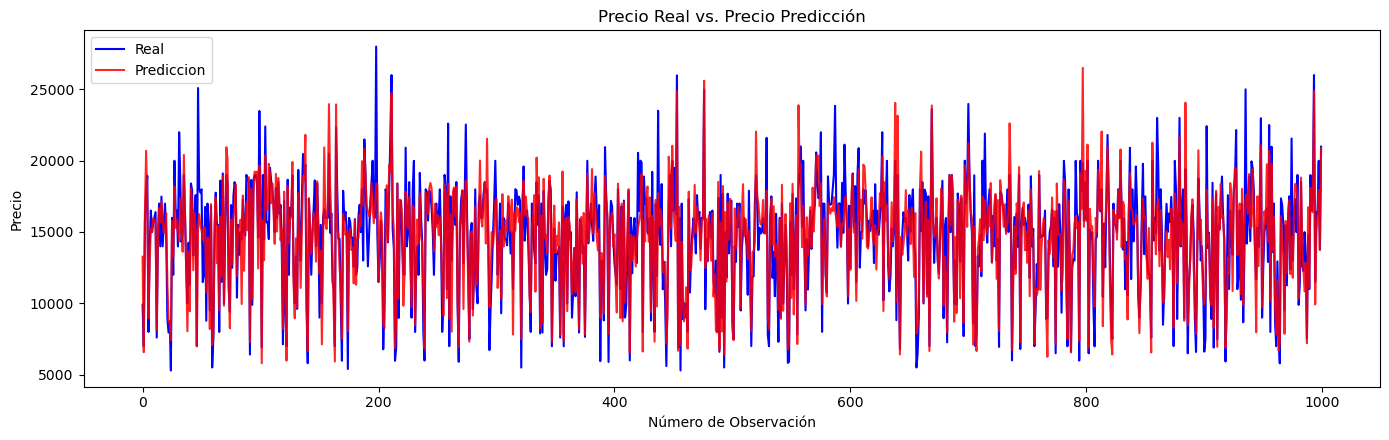

Se obtiene que el modelo resultante cuenta con un RMSE de 1755.2659, un MAE de 1308.3775 y MSE de 3080958.4831

In [121]:
# Celda 4
clf_random = RandomForestRegressor(random_state=40)
clf_random.fit(X_train, y_train)

y_pred_random = clf_random.predict(X_test)
mae_random4 = metrics.mean_absolute_error(y_test, y_pred_random)
mse_random4 = metrics.mean_squared_error(y_test, y_pred_random)
rmse_random4 = np.sqrt(mse_random4)

display(Markdown(f"""Se implementa un modelo Random Forest haciendo uso de la librería sklearn y no se hace modificación de los parámetros"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_random[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_random4:.4f}, un MAE de {mae_random4:.4f} y MSE de {mse_random4:.4f}"""))  

Al implementar un modelo de Random Forest con parámetros por defecto y con semilla 40 para garantizar la reproducibilidad, se obtiene un RMSE de 1755.2. Al tratarse de una predicción de precios, se puede interpretar este RMSE como el error promedio por predicción; en este sentido, cada estimación del precio se desvía alrededor de 1755.2 USD en promedio.

Asimismo, en la gráfica se están comparando los valores reales con las predicciones de las primeras 1000 observaciones. Se puede observar que la predicción, a pesar de presentar un error, sigue la tendencia real de los datos, lo que indica que el modelo logra captar el comportamiento general. Sin embargo, quizás hace falta mejorar la calibración para reducir el error y permitir que las predicciones sean más precisas. Adicionalmente, se puede ver que los datos presentan patrones complejos, ya que tienen una volatilidad muy alta, fluctuando entre valores de 5,000 y 27,000 USD, indicando que se debe mejorar la construcción del modelo para capturar estos patrones complejos.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

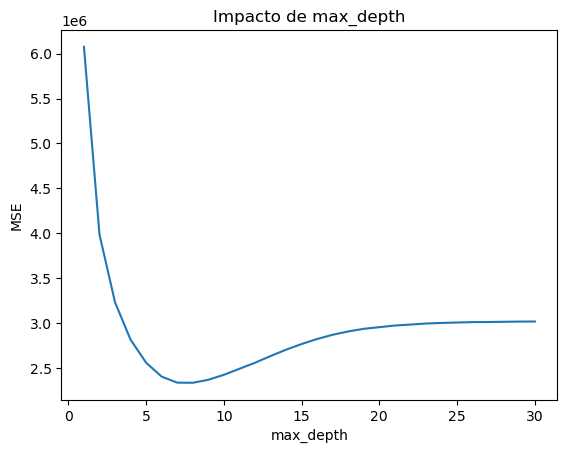

Se minimiza el MSE con max_depth = 8,obteniendo un MSE de **2338049.7881**

In [122]:
depth_range = range(1, 31)
mse_depth = []

for delph in depth_range:
    clf = RandomForestRegressor(max_depth=delph, random_state=40, n_jobs=-1)
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    mse_depth.append(-score)

plt.plot(depth_range, mse_depth)
plt.xlabel('max_depth')
plt.ylabel('MSE')
plt.title('Impacto de max_depth')
plt.show()

best_depth = depth_range[np.argmin(mse_depth)]

display(Markdown(f"""Se minimiza el MSE con max_depth = {best_depth},obteniendo un MSE de **{min(mse_depth):.4f}**"""))

c:\Users\herna\anaconda3\envs\analytics\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\herna\anaconda3\envs\analytics\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\herna\anaconda3\envs\analytics\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\herna\anaconda3\envs\analytics\Lib\site-packag

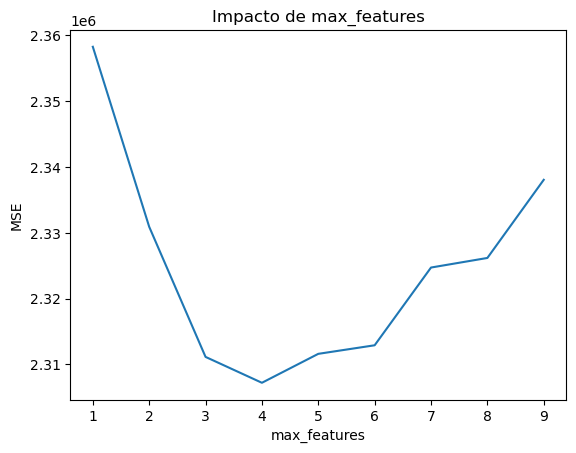

Se minimiza el MSE con max_features = 4,obteniendo un MSE de 2307211.1948

In [123]:
feature_range = range(1, X.shape[1]+1)
mse_features = []

for feature in feature_range:
    clf = RandomForestRegressor(max_depth=8,max_features=feature, random_state=40, n_jobs=-1)
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    mse_features.append(-score)

plt.plot(feature_range, mse_features)
plt.xlabel('max_features')
plt.ylabel('MSE')
plt.title('Impacto de max_features')
plt.show()

best_features = feature_range[np.argmin(mse_features)]

display(Markdown(f"""Se minimiza el MSE con max_features = {best_features},obteniendo un MSE de {min(mse_features):.4f}"""))

Se minimiza el MSE con un valor de n_estimators = 300,obteniendo un MSE de 2300100.4131

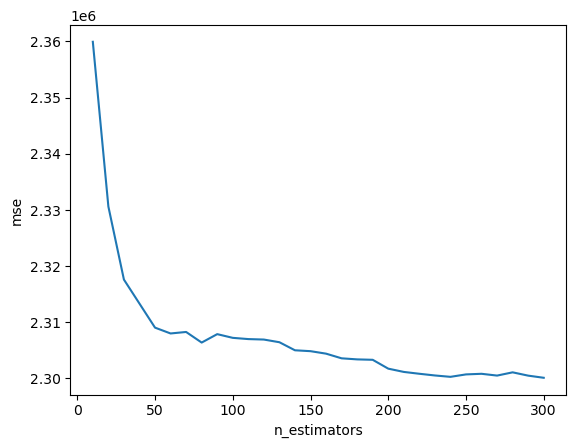

In [124]:
# Celda 5
estimator_range = range(10, 310, 10)
mse_scores = []


for estimator in estimator_range:
    clf = RandomForestRegressor(max_depth=8,max_features=4,n_estimators=estimator, random_state=40, n_jobs=-1)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    mse_scores.append(-scores)  

plt.plot(estimator_range, mse_scores)
plt.xlabel('n_estimators')
plt.ylabel('mse')


best_index = np.argmin(mse_scores)

display(Markdown(f"""Se minimiza el MSE con un valor de n_estimators = {estimator_range[best_index]},obteniendo un MSE de {mse_scores[best_index]:.4f}"""))

In [125]:
clf_random5_1 = RandomForestRegressor(max_depth=8,max_features=4,n_estimators=60,random_state=40)
clf_random5_1.fit(X_train, y_train)

y_pred_random5_1 = clf_random5_1.predict(X_test)
mae_random5_1 = metrics.mean_absolute_error(y_test, y_pred_random5_1)
mse_random5_1 = metrics.mean_squared_error(y_test, y_pred_random5_1)
rmse_random5_1 = np.sqrt(mse_random5_1)

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_random5_1:.4f}, un MAE de {mae_random5_1:.4f} y MSE de {mse_random5_1:.4f}"""))


Se obtiene que el modelo resultante cuenta con un RMSE de 1553.0668, un MAE de 1139.6272 y MSE de 2412016.3517

In [126]:
param_grid = {
    'n_estimators': range(10, 310, 10),
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': range(1, len(X.columns) + 1)
}

clf = RandomForestRegressor(random_state=40, n_jobs=-1)

grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X, y)

best_params = grid_search.best_params_
best_mse = -grid_search.best_score_



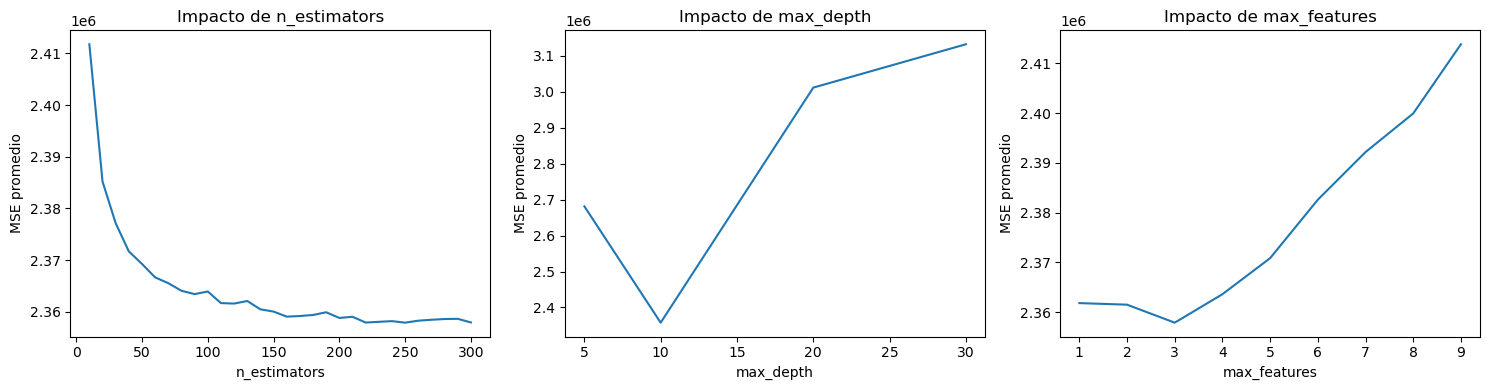


**Mejores parámetros encontrados:**
- n_estimators = 250
- max_depth = 10
- max_features = 3
MSE mínimo: 2357869.6085


In [127]:
results = pd.DataFrame(grid_search.cv_results_)
results['mean_mse'] = -results['mean_test_score']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Impacto de n_estimators
results[
    (results['param_max_depth'] == best_params['max_depth']) &
    (results['param_max_features'] == best_params['max_features'])
].groupby('param_n_estimators')['mean_mse'].mean().plot(ax=axes[0])

axes[0].set_title('Impacto de n_estimators')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('MSE promedio')

# Impacto de max_depth
results[
    (results['param_n_estimators'] == best_params['n_estimators']) &
    (results['param_max_features'] == best_params['max_features'])
].groupby('param_max_depth')['mean_mse'].mean().plot(ax=axes[1])
axes[1].set_title('Impacto de max_depth')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('MSE promedio')

# Impacto de max_features
results[
    (results['param_n_estimators'] == best_params['n_estimators']) &
    (results['param_max_depth'] == best_params['max_depth'])
].groupby('param_max_features')['mean_mse'].mean().plot(ax=axes[2])
axes[2].set_title('Impacto de max_features')
axes[2].set_xlabel('max_features')
axes[2].set_ylabel('MSE promedio')

plt.tight_layout()
plt.show()

display(Markdown(f"""
**Mejores parámetros encontrados:**
- n_estimators = {best_params['n_estimators']}
- max_depth = {best_params['max_depth']}
- max_features = {best_params['max_features']}
MSE mínimo: {best_mse:.4f}
"""))

In [128]:
clf_random5_2 = RandomForestRegressor(max_depth=10,max_features=3,n_estimators=250,random_state=40)
clf_random5_2.fit(X_train, y_train)

y_pred_random5_2 = clf_random5_2.predict(X_test)
mae_random5_2 = metrics.mean_absolute_error(y_test, y_pred_random5_2)
mse_random5_2 = metrics.mean_squared_error(y_test, y_pred_random5_2)
rmse_random5_2 = np.sqrt(mse_random5_2)

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un RMSE de {rmse_random5_2:.4f}, un MAE de {mae_random5_2:.4f} y MSE de {mse_random5_2:.4f}"""))


Se obtiene que el modelo resultante cuenta con un RMSE de 1564.8251, un MAE de 1148.4112 y MSE de 2448677.5557

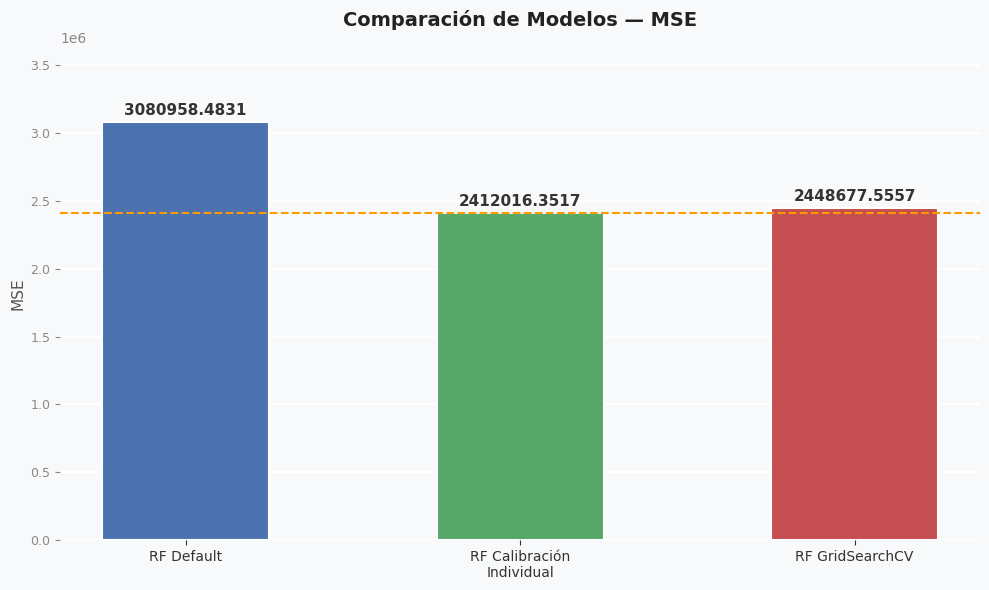

In [129]:
modelos = ["RF Default", "RF Calibración\nIndividual", "RF GridSearchCV"]
mse_values = [mse_random4, mse_random5_1, mse_random5_2]  

colores = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.bar(modelos, mse_values, color=colores, width=0.5,
              edgecolor='white', linewidth=1.5, zorder=3)

ax.yaxis.grid(True, color='white', linewidth=1.5, zorder=0)
ax.set_axisbelow(True)

for bar, val in zip(bars, mse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(mse_values) * 0.01,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )

mejor_mse = min(mse_values)
ax.axhline(y=mejor_mse, color='#FF9900', linewidth=1.5,
           linestyle='--', zorder=4)

ax.set_title('Comparación de Modelos — MSE', fontsize=14,  
             fontweight='bold', color='#222222', pad=15)
ax.set_ylabel('MSE', fontsize=11, color='#555555')         
ax.set_ylim(0, max(mse_values) * 1.18)
ax.tick_params(axis='x', labelsize=10, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#888888')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Se realizó dos implementaciones para la calibración del modelo, a continuación se explica los procedimientos:

**1:** Se realizó una calibración individual de cada uno de los hiperparámetros de forma secuencial; es decir, primero se calibró la profundidad máxima, luego, con el resultado obtenido fijo, se calibró el máximo de variables y, por último, con los dos parámetros anteriores fijos, se calibró el número de árboles.

* En cuanto al comportamiento de la profundidad máxima, se observa que a medida que aumenta este valor el MSE disminuye, aunque llega a un punto mínimo en 8. Esto indica que los valores iniciales presentan una pendiente de caída mucho más pronunciada hasta alcanzar el mínimo, y luego el MSE comienza a aumentar en menor medida.
* En cuanto al comportamiento de la cantidad máxima de características, puede verse como un comportamiento cuadrático donde el mínimo se alcanza en 4. Esto indica que usar pocas variables perjudica al modelo porque, al tener un comportamiento complejo, no lograría capturar los patrones; pero usar demasiadas tampoco es óptimo, ya que no permitiría generar la variabilidad necesaria entre los árboles al no elegir grupos distintos de variables.
* En cuanto al comportamiento del número de árboles, tiene un comportamiento similar al de la profundidad máxima: disminuye rápidamente hasta alcanzar el MSE mínimo en 60 árboles y luego comienza a aumentar en menor medida, similar a una función exponencial inversa.

Con esta metodología se alcanzó un MSE de 2,412,016 y un RMSE de 1,553.06, obtenido con los parámetros max_depth = 8, max_features = 4 y n_estimators = 60.

**2:** La segunda metodología utilizó GridSearchCV para realizar una optimización conjunta de los hiperparámetros, lo que permite encontrar la mejor combinación evaluándolos simultáneamente y no de forma separada, evitando así que el resultado de un parámetro afecte independientemente a los demás. En este caso, se usaron los mismos rangos que en la metodología anterior para mantener condiciones comparables.

* En cuanto al comportamiento de la profundidad máxima, presenta un comportamiento en forma de "V" con un mínimo claro en 10, a partir del cual el MSE comienza a aumentar, lo que indica que profundidades mayores conducen a sobreajuste y deterioran el desempeño del modelo.
* En cuanto al comportamiento de la cantidad máxima de características, muestra un comportamiento similar a una función exponencial inversa a lo largo de todo el rango evaluado, lo que sugiere que considerar más variables en cada división permite capturar mejor los patrones complejos del dataset, siendo el valor óptimo el máximo evaluado (9 variables).
* En cuanto al comportamiento del número de árboles, presenta un patrón similar a la metodología anterior, con una caída continua del MSE a medida que aumenta el número de árboles, siendo el valor mínimo alcanzado en 300.

Sin embargo, el comportamiento individual de cada parámetro no determina directamente el valor seleccionado, ya que GridSearchCV evalúa todas las combinaciones posibles y selecciona la óptima en conjunto. En este caso, se respetó el mínimo de profundidad en 10, pero se seleccionaron 250 árboles y solo 3 variables, obteniendo un RMSE de 1,564.83 y un MSE de 2,448,677.

**Comparación Métricas:** Al observar ambas metodologías, se puede determinar que cada una llega a parámetros distintos: la primera utiliza una profundidad de 8 mientras que la segunda usa 10; 60 árboles en la primera frente a 250 en la segunda; y 4 variables en la primera contra 3 en la segunda. Se puede observar que ambas metodologías optan por valores intermedios en max_features, lo que se explica porque Random Forest requiere que cada árbol evalúe un subconjunto de variables para generar variabilidad entre ellos, si se usaran todas, los árboles serían muy similares entre sí y se perdería el beneficio del ensamble. En cuanto a la profundidad, ambas optan por valores medios, ya que logran capturar los patrones del dataset sin llegar a sobreajuste, lo cual ocurriría con valores muy grandes.

La principal diferencia radica en el número de árboles. Esto se puede explicar por la naturaleza de cada metodología: en la calibración individual, n_estimators fue el último parámetro calibrado con los otros ya fijos, por lo que el modelo encontró que con esa combinación específica 60 árboles eran suficientes para alcanzar el óptimo. En cambio, GridSearchCV al evaluar todas las combinaciones simultáneamente, optó por usar menos variables pero compensar con más árboles para estabilizar el ensamble y alcanzar su combinación óptima.

**Comparación Modelos:** En cuanto a la comparación de modelos, se encontró que el mejor modelo es el RF con calibración individual, seguido de la optimización por GridSearchCV y finalmente el modelo por defecto. En cuanto a las calibraciones, hubo una diferencia de 36,661 puntos de MSE, lo cual es relativamente baja e indica que aunque ambas metodologías arrojen resultados distintos, cualquiera podría ser una elección válida. En cambio, frente al modelo por defecto, se evidencia que sí es necesario realizar una calibración para mejorar la predicción en casi un 25%.

En cuanto al modelo elegido, se obtuvo un RMSE de 1,553.06 USD, lo que significa que por cada predicción el modelo presenta un error promedio de 1,553 dólares, representando aproximadamente un error relativo del 9-10% sobre el precio promedio, considerado aceptable dada la alta volatilidad del dataset. Por otro lado, el MAE de 1,139 USD, al ser una métrica menos sensible a valores extremos y al ser inferior al RMSE, confirma que existen errores puntuales grandes que inflan esta última métrica, lo que indica que el modelo presenta mayores dificultades cuando se trata de predecir precios en los picos extremos del dataset.

### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

Se implementa un modelo Xtreme Gradient Boosting haciendo uso de la librería sklearn y no se hace modificación de los parámetros

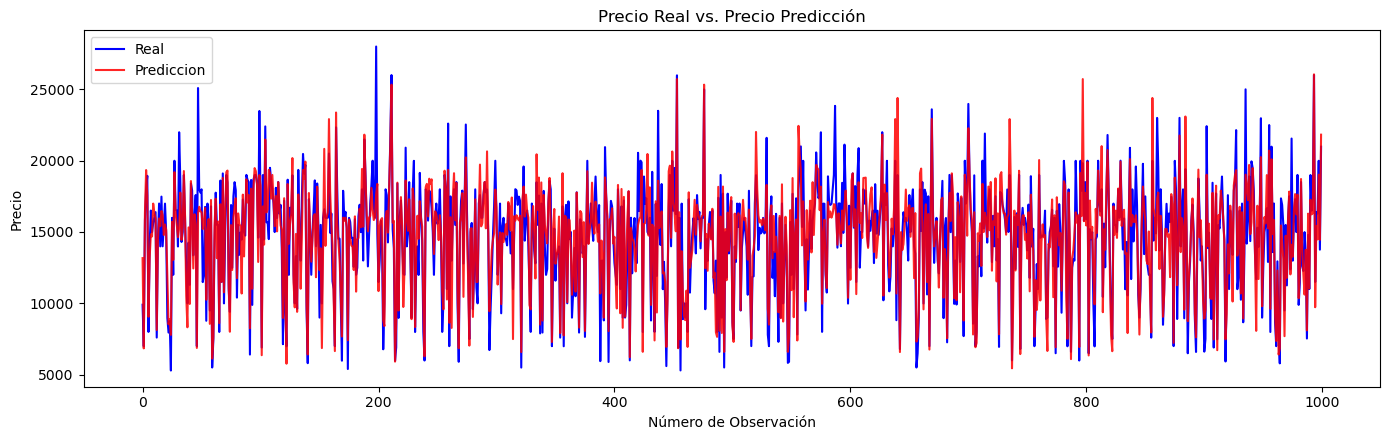

Se obtiene que el modelo resultante cuenta con un ***MSE de 2576781.0000***, ***RMSE de 1605.2355*** y un ***MAE de 1185.2273***.

In [130]:
# Celda 6
clf = XGBRegressor(random_state=60)
clf.fit(X_train, y_train)

y_pred_xgb = clf.predict(X_test)
mae_xgb = metrics.mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = metrics.mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

display(Markdown(f"""Se implementa un modelo Xtreme Gradient Boosting haciendo uso de la librería sklearn y no se hace modificación de los parámetros"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_xgb[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un ***MSE de {mse_xgb:.4f}***, ***RMSE de {rmse_xgb:.4f}*** y un ***MAE de {mae_xgb:.4f}***."""))

In [131]:
clf.get_booster().save_config()

'{"learner":{"generic_param":{"device":"cpu","fail_on_invalid_gpu_id":"0","n_jobs":"0","nthread":"0","random_state":"60","seed":"60","seed_per_iteration":"0","validate_parameters":"1"},"gradient_booster":{"gbtree_model_param":{"num_parallel_tree":"1","num_trees":"100"},"gbtree_train_param":{"process_type":"default","tree_method":"auto","updater":"grow_quantile_histmaker","updater_seq":"grow_quantile_histmaker"},"name":"gbtree","specified_updater":false,"tree_train_param":{"alpha":"0","colsample_bylevel":"1","colsample_bynode":"1","colsample_bytree":"1","eta":"0.300000012","gamma":"0","grow_policy":"depthwise","interaction_constraints":"","lambda":"1","learning_rate":"0.300000012","max_bin":"256","max_cat_threshold":"64","max_cat_to_onehot":"4","max_delta_step":"0","max_depth":"6","max_leaves":"0","min_child_weight":"1","min_split_loss":"0","monotone_constraints":"()","refresh_leaf":"1","reg_alpha":"0","reg_lambda":"1","sampling_method":"uniform","sparse_threshold":"0.20000000000000001"

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

La calibracion manual se hace de forma secuencial, a diferencia de Random Forest los arboles no son independientes
                 por tanto importa la interaccion de los parametros a calibrar y el orden en el que estos se calibren. De igua forma,
                 tambien se realiza calibración por GridSearch con el fin de evaluar combinaciones que se decartan por calibrar de forma
                 manual y secuencial. Por ejemplo, si el modelo tiene una tasa de aprendizaje muy alta,
                 puede que un gamma alto sea necesario para reducir el overfitting, por el contrario, si la tasa de aprendizaje
                 es baja, puede que el valor optimo de gamma sea menor ya que no se hace necesario corregir el overfitting.

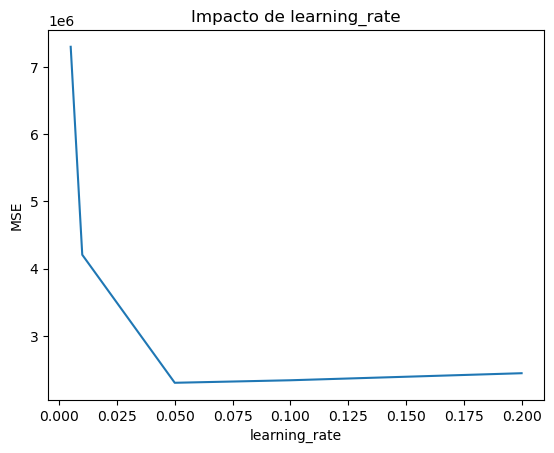

El learning rate determina que tanto se corrige el arbol anterior, si corrige muy rapido hay riesgo de overfitting.
                 
En este caso se minimiza el MSE con learning_rate = **0.05**,obteniendo un MSE de **2302128.0500**

In [132]:
# Celda 7
display(Markdown("""La calibracion manual se hace de forma secuencial, a diferencia de Random Forest los arboles no son independientes
                 por tanto importa la interaccion de los parametros a calibrar y el orden en el que estos se calibren. De igua forma,
                 tambien se realiza calibración por GridSearch con el fin de evaluar combinaciones que se decartan por calibrar de forma
                 manual y secuencial. Por ejemplo, si el modelo tiene una tasa de aprendizaje muy alta,
                 puede que un gamma alto sea necesario para reducir el overfitting, por el contrario, si la tasa de aprendizaje
                 es baja, puede que el valor optimo de gamma sea menor ya que no se hace necesario corregir el overfitting."""))

#learaning rate
lr_range = [0.005, 0.01, 0.05, 0.1, 0.2]
mse_lr = []

for lr in lr_range:
    clf = XGBRegressor(
        learning_rate=lr,
        random_state=60,
        n_jobs=-1
    )
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    mse_lr.append(-score)

plt.plot(lr_range, mse_lr)
plt.xlabel('learning_rate')
plt.ylabel('MSE')
plt.title('Impacto de learning_rate')
plt.show()

best_lr = lr_range[np.argmin(mse_lr)]

display(Markdown(f"""El learning rate determina que tanto se corrige el arbol anterior, si corrige muy rapido hay riesgo de overfitting.
                 \nEn este caso se minimiza el MSE con learning_rate = **{best_lr}**,obteniendo un MSE de **{min(mse_lr):.4f}**"""))


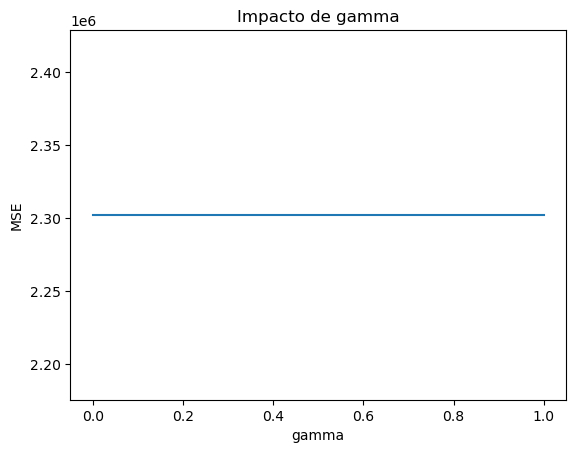

Gamma representa la ganacia minima para hacer split, si el modelo no mejora lo suficiente no se hacen mas splits,
                 es entonces un parametro que controla la complejidad del arbol, entre mas grande, menos splits.
                 En este escenario, se minimiza el MSE con gamma = 0,obteniendo un MSE de **2302128.0500**
                 
En la representacion visual se puede ver que el modelo no es sensible a cambios en gamma, esto implica que el
                 no se esta sobreajustando por la estructura del arbol y por tanto no es necesario imponer condiciones que simplifiquen
                 dicha estructura.

In [133]:

#Gamma

gamma_range = [0, 0.1, 0.2, 0.5, 1]
mse_gamma = []

for gamma in gamma_range:
    clf = XGBRegressor(
        learning_rate=best_lr,
        gamma=gamma,
        random_state=60,
        n_jobs=-1
    )
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    mse_gamma.append(-score)

plt.plot(gamma_range, mse_gamma)
plt.xlabel('gamma')
plt.ylabel('MSE')
plt.title('Impacto de gamma')
plt.show()

best_gamma = gamma_range[np.argmin(mse_gamma)]

display(Markdown(f"""Gamma representa la ganacia minima para hacer split, si el modelo no mejora lo suficiente no se hacen mas splits,
                 es entonces un parametro que controla la complejidad del arbol, entre mas grande, menos splits.
                 En este escenario, se minimiza el MSE con gamma = {best_gamma},obteniendo un MSE de **{min(mse_gamma):.4f}**
                 \nEn la representacion visual se puede ver que el modelo no es sensible a cambios en gamma, esto implica que el
                 no se esta sobreajustando por la estructura del arbol y por tanto no es necesario imponer condiciones que simplifiquen
                 dicha estructura."""))


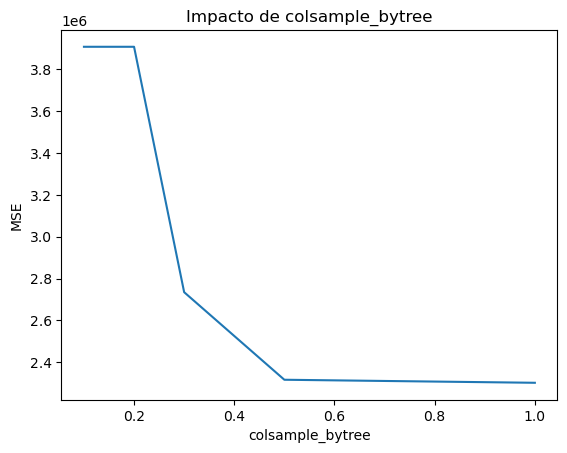

colsample_bytree representa la proporcion de variables o features usadas en cada arbol,
                 entre menos sea, mas aleatorios y menor correlación entre arboles, esto se traduce en menor posibilida
                 de overfitting.
                 Se minimiza el MSE con colsample_bytree = 1,obteniendo un MSE de **2302128.0500**
                 
En este caso usar todas las variables no genera sobreajuste y al contrario minimiza el MSE de CV

In [134]:
#colsample_bytree

colsample_range = [0.1, 0.2, 0.3, 0.5, 1]
mse_colsample = []

for colsample in colsample_range:
    clf = XGBRegressor(
        learning_rate=best_lr,
        gamma=best_gamma,
        colsample_bytree=colsample,
        random_state=60,
        n_jobs=-1
    )
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
    mse_colsample.append(-score)

plt.plot(colsample_range, mse_colsample)
plt.xlabel('colsample_bytree')
plt.ylabel('MSE')
plt.title('Impacto de colsample_bytree')
plt.show()

best_colsample = colsample_range[np.argmin(mse_colsample)]

display(Markdown(f"""colsample_bytree representa la proporcion de variables o features usadas en cada arbol,
                 entre menos sea, mas aleatorios y menor correlación entre arboles, esto se traduce en menor posibilida
                 de overfitting.
                 Se minimiza el MSE con colsample_bytree = {best_colsample},obteniendo un MSE de **{min(mse_colsample):.4f}**
                 \nEn este caso usar todas las variables no genera sobreajuste y al contrario minimiza el MSE de CV"""))


Se implementa un modelo Xtreme Gradient Boosting con los parámetros obtenidos en la calibración manual.

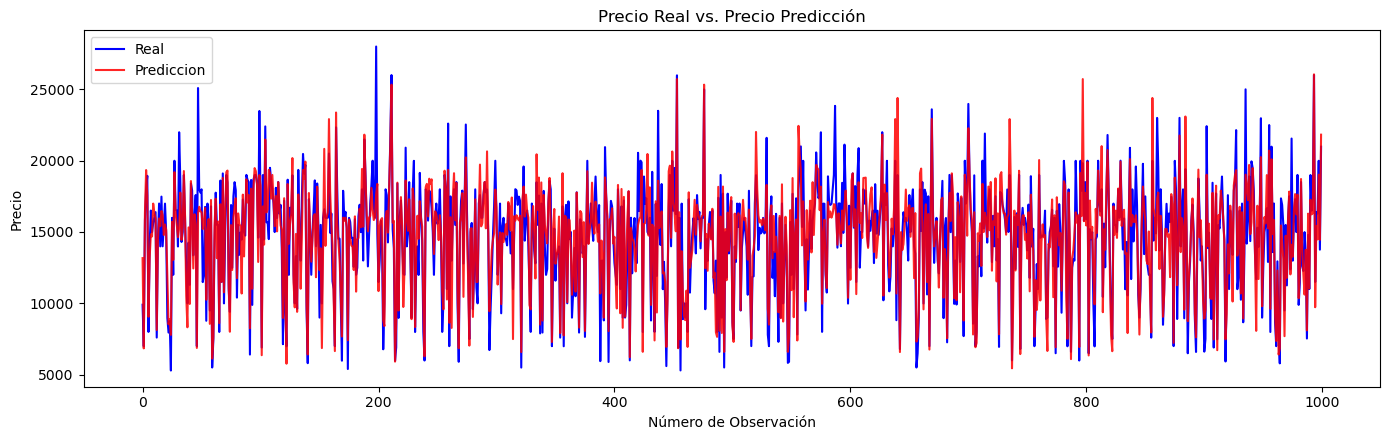

Se obtiene que el modelo resultante cuenta con un ***MSE de 2414313.5000***, ***RMSE de 1553.8061*** y un ***MAE de 1138.9441***.

In [135]:
#mejor modelo
clf = XGBRegressor(
    learning_rate=best_lr,
    gamma=best_gamma,
    colsample_bytree=best_colsample,
    random_state=60,
    n_jobs=-1
    )

clf.fit(X_train, y_train)

y_pred_xgb_opt = clf.predict(X_test)
mae_xgb_opt = metrics.mean_absolute_error(y_test, y_pred_xgb_opt)
mse_xgb_opt = metrics.mean_squared_error(y_test, y_pred_xgb_opt)
rmse_xgb_opt = np.sqrt(mse_xgb_opt)

display(Markdown(f"""Se implementa un modelo Xtreme Gradient Boosting con los parámetros obtenidos en la calibración manual."""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_xgb[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un ***MSE de {mse_xgb_opt:.4f}***, ***RMSE de {rmse_xgb_opt:.4f}*** y un ***MAE de {mae_xgb_opt:.4f}***."""))

In [136]:
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gamma': [0, 0.1, 0.2, 0.5, 1],
    'colsample_bytree': [0.1, 0.2, 0.3, 0.5, 1]
}

clf = XGBRegressor(
    random_state=60,
    n_jobs=-1
    )

grid_search = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_mse = -grid_search.best_score_

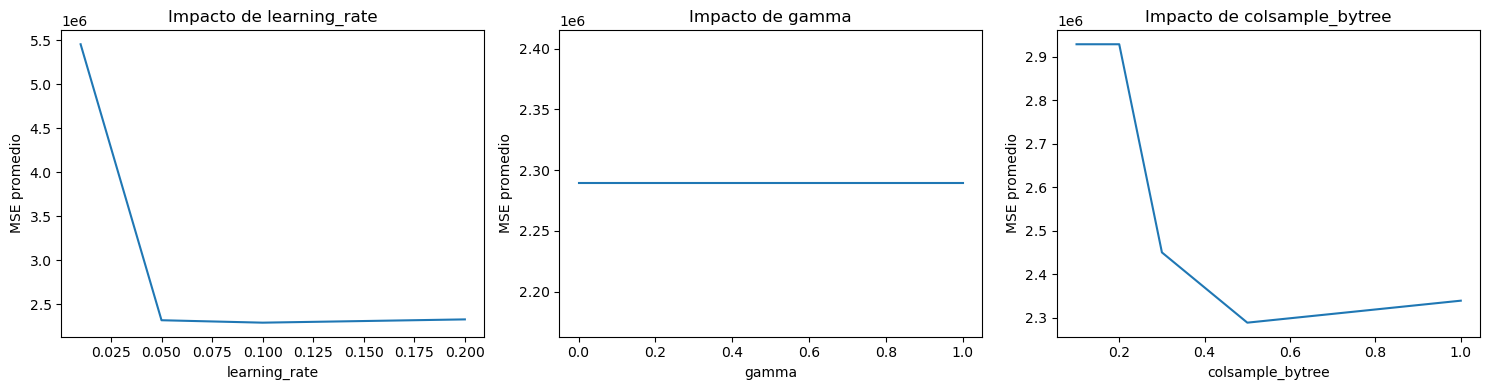

Debido a la interacción de variables que se menciono anteriomente, se opta por realizar
                 calibración usando GridSearch:


**Mejores parámetros encontrados:**
- learning_rate = 0.1
- param_gamma = 0
- colsample_bytree = 0.5
MSE mínimo: 2289041.3250


De nuevo no es necesario restringir la complejidad del arbol por medio de Gamma, pero si se reduce
                 el pull de variables usadas en los arboles, como respuesta a una mayor tasa de aprendizaje.

In [137]:
results = pd.DataFrame(grid_search.cv_results_)
results['mean_mse'] = -results['mean_test_score']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Impacto de learning_rate
results[
    (results['param_gamma'] == best_params['gamma']) &
    (results['param_colsample_bytree'] == best_params['colsample_bytree'])
].groupby('param_learning_rate')['mean_mse'].mean().plot(ax=axes[0])
axes[0].set_title('Impacto de learning_rate')
axes[0].set_xlabel('learning_rate')
axes[0].set_ylabel('MSE promedio')

# Impacto de gamma
results[
    (results['param_learning_rate'] == best_params['learning_rate']) &
    (results['param_colsample_bytree'] == best_params['colsample_bytree'])
].groupby('param_gamma')['mean_mse'].mean().plot(ax=axes[1])
axes[1].set_title('Impacto de gamma')
axes[1].set_xlabel('gamma')
axes[1].set_ylabel('MSE promedio')

# Impacto de colsample_bytree
results[
    (results['param_learning_rate'] == best_params['learning_rate']) &
    (results['param_gamma'] == best_params['gamma'])
].groupby('param_colsample_bytree')['mean_mse'].mean().plot(ax=axes[2])
axes[2].set_title('Impacto de colsample_bytree')
axes[2].set_xlabel('colsample_bytree')
axes[2].set_ylabel('MSE promedio')

#para cada uno no se promedio sobre todos los valores, sino que se fijan para que efectivamente se ve graficamente el mejor
plt.tight_layout()
plt.show()

display(Markdown("""Debido a la interacción de variables que se menciono anteriomente, se opta por realizar
                 calibración usando GridSearch:"""))

display(Markdown(f"""
**Mejores parámetros encontrados:**
- learning_rate = {best_params['learning_rate']}
- param_gamma = {best_params['gamma']}
- colsample_bytree = {best_params['colsample_bytree']}
MSE mínimo: {best_mse:.4f}
"""))
display(Markdown("""De nuevo no es necesario restringir la complejidad del arbol por medio de Gamma, pero si se reduce
                 el pull de variables usadas en los arboles, como respuesta a una mayor tasa de aprendizaje."""))

Se implementa un modelo Xtreme Gradient Boosting con los parámetros calibrados por GridSearch

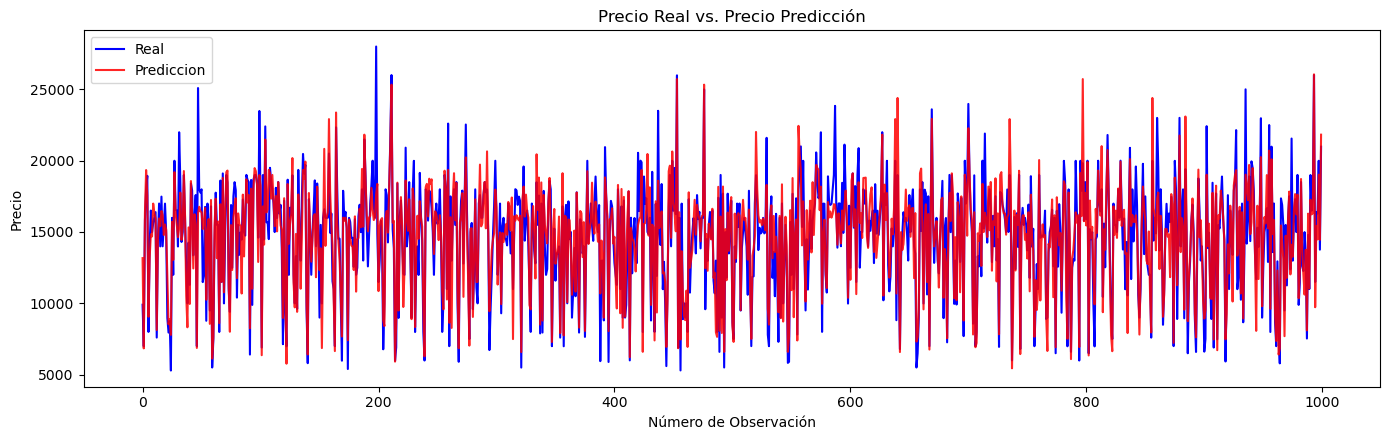

Se obtiene que el modelo resultante cuenta con un ***MSE de 2404394.2500***, ***RMSE de 1550.6109*** y un ***MAE de 1139.3458***.

In [138]:
#mejor modelo
#grid search evalua interacciones que yo no por hacerlo secuncial
clf = XGBRegressor(
    learning_rate=0.1,
    gamma=0,
    colsample_bytree=0.5,
    random_state=60,
    n_jobs=-1
    )

clf.fit(X_train, y_train)

y_pred_xgb_opt_gs = clf.predict(X_test)
mae_xgb_opt_gs = metrics.mean_absolute_error(y_test, y_pred_xgb_opt_gs)
mse_xgb_opt_gs = metrics.mean_squared_error(y_test, y_pred_xgb_opt_gs)
rmse_xgb_opt_gs = np.sqrt(mse_xgb_opt_gs)

display(Markdown(f"""Se implementa un modelo Xtreme Gradient Boosting con los parámetros calibrados por GridSearch"""))

#Gráfica
plt.figure(figsize=(14, 4.5))
plt.plot(y_test.values[:1000], color='blue', label='Real')
plt.plot(y_pred_xgb[:1000], color='red', label='Prediccion', alpha=0.85)
plt.title('Precio Real vs. Precio Predicción')
plt.xlabel('Número de Observación')
plt.ylabel('Precio')
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown(f"""Se obtiene que el modelo resultante cuenta con un ***MSE de {mse_xgb_opt_gs:.4f}***, ***RMSE de {rmse_xgb_opt_gs:.4f}*** y un ***MAE de {mae_xgb_opt_gs:.4f}***."""))

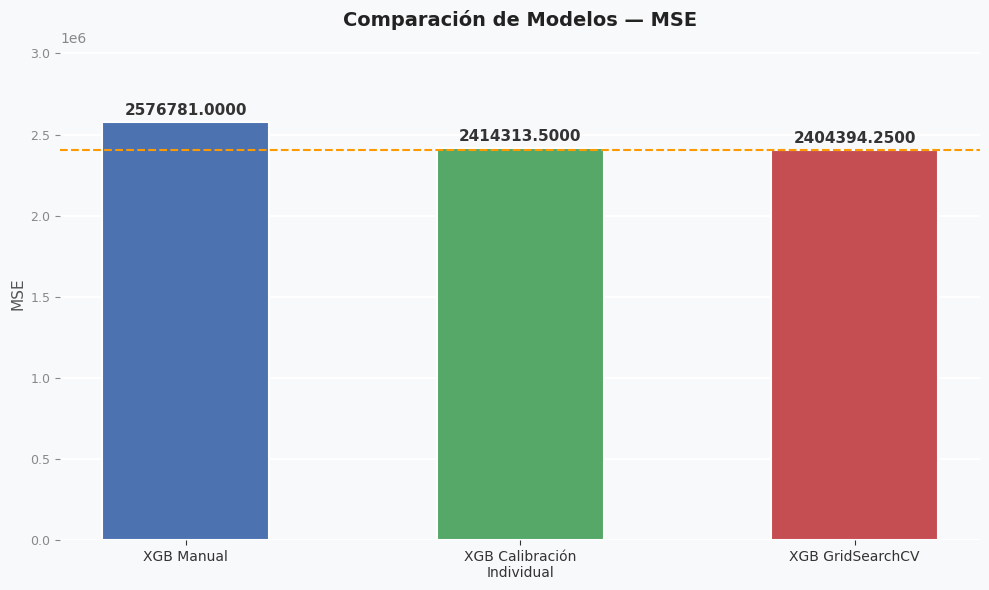

In [143]:
modelos = ["XGB Manual", "XGB Calibración\nIndividual", "XGB GridSearchCV"]
mse_values = [mse_xgb, mse_xgb_opt, mse_xgb_opt_gs]  

colores = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.bar(modelos, mse_values, color=colores, width=0.5,
              edgecolor='white', linewidth=1.5, zorder=3)

ax.yaxis.grid(True, color='white', linewidth=1.5, zorder=0)
ax.set_axisbelow(True)

for bar, val in zip(bars, mse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(mse_values) * 0.01,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )

mejor_mse = min(mse_values)
ax.axhline(y=mejor_mse, color='#FF9900', linewidth=1.5,
           linestyle='--', zorder=4)

ax.set_title('Comparación de Modelos — MSE', fontsize=14,  
             fontweight='bold', color='#222222', pad=15)
ax.set_ylabel('MSE', fontsize=11, color='#555555')         
ax.set_ylim(0, max(mse_values) * 1.18)
ax.tick_params(axis='x', labelsize=10, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#888888')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

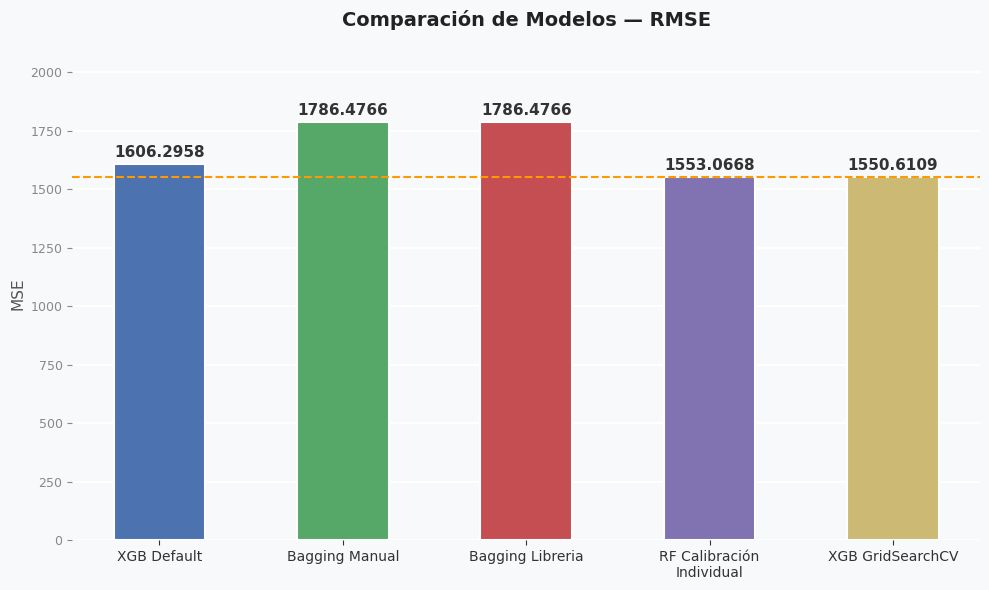

In [144]:
# Celda 8
modelos = ["XGB Default", "Bagging Manual", "Bagging Libreria", "RF Calibración\nIndividual", "XGB GridSearchCV"]
rmse_values = [best_rmse, rmse_bagg_m, rmse_bagg, rmse_random5_1, rmse_xgb_opt_gs]  

colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.bar(modelos, rmse_values, color=colores, width=0.5,
              edgecolor='white', linewidth=1.5, zorder=3)

ax.yaxis.grid(True, color='white', linewidth=1.5, zorder=0)
ax.set_axisbelow(True)

for bar, val in zip(bars, rmse_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(rmse_values) * 0.01,
        f'{val:.4f}',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='#333333'
    )
    

mejor_mse = min(rmse_values)
ax.axhline(y=mejor_mse, color='#FF9900', linewidth=1.5,
           linestyle='--', zorder=4)

ax.set_title('Comparación de Modelos — RMSE', fontsize=14,  
             fontweight='bold', color='#222222', pad=15)
ax.set_ylabel('MSE', fontsize=11, color='#555555')         
ax.set_ylim(0, max(rmse_values) * 1.18)
ax.tick_params(axis='x', labelsize=10, colors='#333333')
ax.tick_params(axis='y', labelsize=9, colors='#888888')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()